# PyTorch Datasets and DataLoaders
This demo covers PyTorch Datasets and DataLoaders. We will pickup and cover the topics from the video. 

# PyTorch Datasets

### PyTorch Pre-loaded Datasets
Let's begin by covering "pre-loaded" Datasets in PyTorch

These are perfect for beginning working with Datasets or for research/experimentation.

Pre-loaded Datasets available: Image, Text and Audio

In [ ]:
# 【说明】本单元仅导入 torchaudio 的数据集模块，后续可用它构造官方音频数据集
# 这里不下载任何数据，只做模块准备
# Let's begin with Pre-loaded Audio files
# Import torchaudio 
import torchaudio.datasets

# To get a list of available Audio Datasets go to Documentation URL: https://pytorch.org/audio/stable/datasets.html

In [ ]:
# 【说明】本单元演示如何创建并下载官方音频数据集（DR_VCTK）
# root='./audio' 表示数据会存到当前目录下 audio 文件夹
# subset='test' 表示只加载测试子集，download=True 表示本地没有就下载
# Create a dataset using DR_VCTK (Device Recorded VCTK https://pytorch.org/audio/stable/references.html#id42)
import os

# 创建目录
os.makedirs('./audio', exist_ok=True)

# 现在可以下载了
audio_dataset = torchaudio.datasets.DR_VCTK(root='./audio', subset='test', download=True)



100%|██████████| 1.67G/1.67G [01:40<00:00, 17.8MB/s]


KeyboardInterrupt: 

In [ ]:
# 【说明】切换到图像数据集示例，导入 torchvision 的数据集接口与 ToTensor 转换
# ToTensor 会把 PIL 图像/ndarray 转成模型可用的张量格式 [C, H, W]
# Lets do a pre-loaded image dataset
# Import the torchvision datasets library
import torchvision.datasets
from torchvision.transforms import ToTensor

In [ ]:
# 【说明】创建 FashionMNIST 数据集对象（官方手写服饰分类数据）
# train=False: 使用测试集；download=True: 本地无数据时自动下载
# transform=ToTensor(): 每次取样时自动把图片转成 tensor
# Create a dataset from the FashionMNIST classification dataset 
image_dataset = torchvision.datasets.FashionMNIST(root='./fashion', train=False, download=True, transform=ToTensor())

# NOTE: Ignore the transform for now. Tensors are required. 

In [ ]:
# 【说明】查看数据集的类别名称列表
# 例如 FashionMNIST 会返回 10 个类别名：T-shirt/top, Trouser ...
# Let's print the Classes of a dataset 
print(image_dataset.classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
# 【说明】查看“类别名 -> 数字索引”映射
# 模型训练时通常只接收数值标签，因此这个映射非常关键
# Print the classes to their indexes 
print(image_dataset.class_to_idx)

# This is an attribute used to map class names to integer values because models require integer values for training


{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


In [ ]:
# 【说明】将 class_to_idx 反转成“索引 -> 类别名”，便于后续可视化标题显示
# 训练阶段模型输出是索引值，人类阅读时更适合看类别名称
# Reverse the class to index mapping for plotting
class_to_index_map = image_dataset.class_to_idx
index_to_class_map = {v: k for k, v in class_to_index_map.items()}
print(index_to_class_map)

{0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}


In [ ]:
# 【说明】演示如何从数据集中取单个样本：返回 (image_tensor, label)
# 这里取第 0 个样本并打印张量形状与标签索引
import torchvision.datasets as dsets
from torchvision.transforms import ToTensor

ds = dsets.FashionMNIST(root="./fashion", train=False, download=False, transform=ToTensor())
img, label = ds[0]
print(img.shape, label)

torch.Size([1, 28, 28]) 9


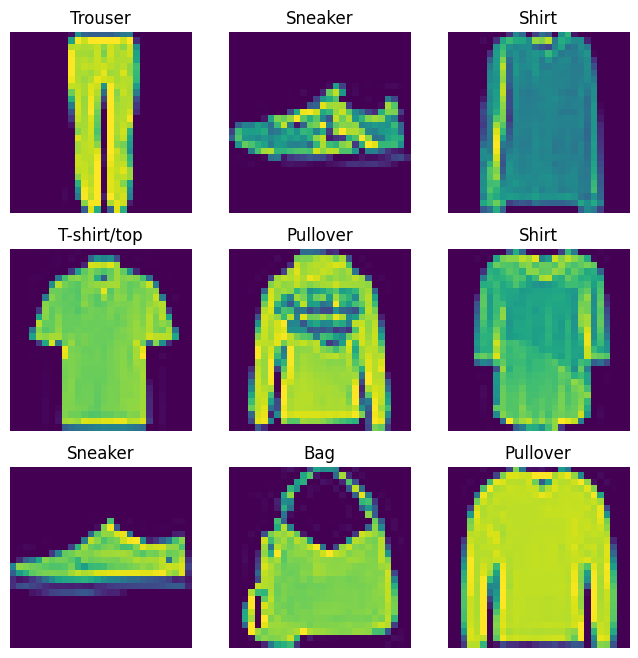

In [ ]:
# 【说明】随机可视化 9 张样本图，快速检查数据是否正确读取与标注
# 这是训练前常见的数据检查步骤（sanity check）
# Lets get a visual of our dataset with 9 random images
import torch
import matplotlib.pyplot as plt


# Set up our plot
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(image_dataset), size=(1,)).item()
    img, label = image_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(index_to_class_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze())
plt.show()

# PyTorch DataLoaders
Now that we have a working dataset, lets begin defining how we are going to present or load our data to our model.

This is done using DataLoaders!

In [ ]:
# 【说明】导入 DataLoader，用于把 Dataset 打包成“批次（batch）”供模型训练
# Import DataLoader
from torch.utils.data import DataLoader

In [ ]:
# 【说明】构建 DataLoader：
# batch_size=64 表示每次迭代返回 64 条样本
# shuffle=True 每个 epoch 打乱顺序，降低训练偏差
# num_workers=1 使用 1 个子进程预取数据
# Create a new dataloader from our image_dataset above
image_dataloader = DataLoader(dataset=image_dataset, batch_size=64, shuffle=True, num_workers=1)

### DataLoader Parameters review
batch_size: Number of samples (images) are loaded at a time.

shuffle: When True, images are randomized before sending to the model.

num_workers: Number of processes to use for loading data. 

In [ ]:
# 【说明】从 DataLoader 中取出一个 batch
# features 是图像张量批次，labels 是对应标签批次
# iterate through the image_dataloader
features, labels = next(iter(image_dataloader))
# Print the batch size and the number of labels
print(f"Features shape: {features.size()}")
print(f"Labels shape: {labels.size()}")

Features shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


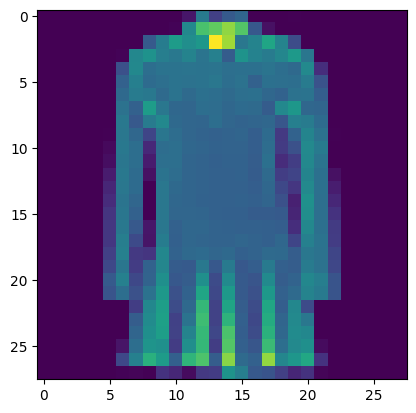

Label: 3 -> Dress


In [ ]:
# 【说明】从当前 batch 随机抽一张图，显示并把标签索引映射为类别名
# 方便确认 DataLoader 产出的数据与标签是一一对应的
# Show image with its label from a random image in our batch
import random

# Get a random value between 0 and our batch size
rand_indx = random.randint(0, labels.size()[0])

# set image and label
img = features[rand_indx].squeeze()
label = labels[rand_indx]

# Plot the image
plt.imshow(img)
plt.show()

# Print its label and map its numeric value to the actual name of its class
print(f"Label: {label} -> {index_to_class_map[label.item()]}")

# Review
So far we have created Datasets using PyTorch's pre-loaded datasets.

We have also created a DataLoader used to define our to present our dataset to our model.

# Custom Datasets
Lets take a look at how to create custom datasets in Pytorch using our own existing images.

In [ ]:
# 【说明】导入 Dataset 基类，自定义数据集时需要继承它
# Import Dataset
from torch.utils.data import Dataset

In [ ]:
# 【说明】自定义数据集核心模板：
# 1) __init__: 读取标注文件并初始化映射
# 2) __len__: 返回样本数量
# 3) __getitem__: 按索引读取样本并返回 (image_tensor, label, path)
import pandas as pd
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset


# Define our Dataset Class
class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, class_list):
        self.df = pd.read_csv(annotations_file)
        self.class_list = class_list
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(class_list)}

    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, index):
        image = Image.open(self.df.file_path[index])
        img_url = self.df.file_path[index]
        # Images must be tensors. Ignore transformations for now.
        convert_tensor = transforms.ToTensor()
        image = convert_tensor(image)
        label = self.class_to_idx[self.df.label[index]]

        return image, label, img_url

In [ ]:
# 【说明】本单元是文档说明型单元，用三引号字符串总结 Dataset 三个关键方法
"""
Dataset Class Review

__init__ method: Peforms initial setup and load the data. 

__len__ method: Returns the number of samples for batch.

__getitem__ method: Retrieves a single data sample based on an index.

"""
"""
数据集类回顾

__init__方法：执行初始设置并加载数据。

__len__方法：返回用于批处理的样本数量。

__getitem__方法：根据索引检索单个数据样本。
"""

'\nDataset Class Review\n\n__init__ method: Peforms initial setup and load the data. \n\n__len__ method: Returns the number of samples for batch.\n\n__getitem__ method: Retrieves a single data sample based on an index.\n\n'

In [ ]:
# 【说明】定义自定义数据集的类别顺序
# 顺序很重要：它决定了类别到数字标签的映射（cat->0, dog->1）
# Lets create our custom dataset!
# We must define an annotations file and a list of classes
class_list = ["cat", "dog"]

In [ ]:
# 【说明】实例化自定义数据集对象
# annotations_file 提供图片路径与标签，class_list 提供类别词表
# Create custom dataset
custom_dataset = CustomImageDataset(annotations_file='labels.csv', class_list=class_list)
print(custom_dataset)

In [ ]:
# 【说明】查看读取到的标注表（通常包含 file_path 与 label 列）
# 这是检查 CSV 是否被正确加载的关键一步
# Print attributes of our dataset (__init__ method)

# Display our annotations
print(f"Annotations data: \n{custom_dataset.df}") 

Annotations data: 
              file_path label
0  images/cat/cat-1.jpg   cat
1  images/cat/cat-2.jpg   cat
2  images/cat/cat-3.jpg   cat
3  images/cat/cat-4.jpg   cat
4  images/cat/cat-5.jpg   cat
5  images/dog/dog-1.jpg   dog
6  images/dog/dog-2.jpg   dog
7  images/dog/dog-3.jpg   dog
8  images/dog/dog-4.jpg   dog
9  images/dog/dog-5.jpg   dog


In [ ]:
# 【说明】查看类别列表，确认类别顺序与预期一致
# Show our classes
print(f"Classes: {custom_dataset.class_list}")

Classes: ['cat', 'dog']


In [ ]:
# 【说明】打印类别到索引的映射，训练时会把文本标签转成数值标签
# Show our class to index map
print(f"Mapped Classes: {custom_dataset.class_to_idx}")

Mapped Classes: {'cat': 0, 'dog': 1}


In [ ]:
# 【说明】手动定义“索引 -> 类别名”映射，便于可视化时把数字标签还原成人类可读文本
# Create our own mapper OR we could add this in our __getitem__ method
custom_class_labels_map = {0: 'cat', 1: 'dog'}

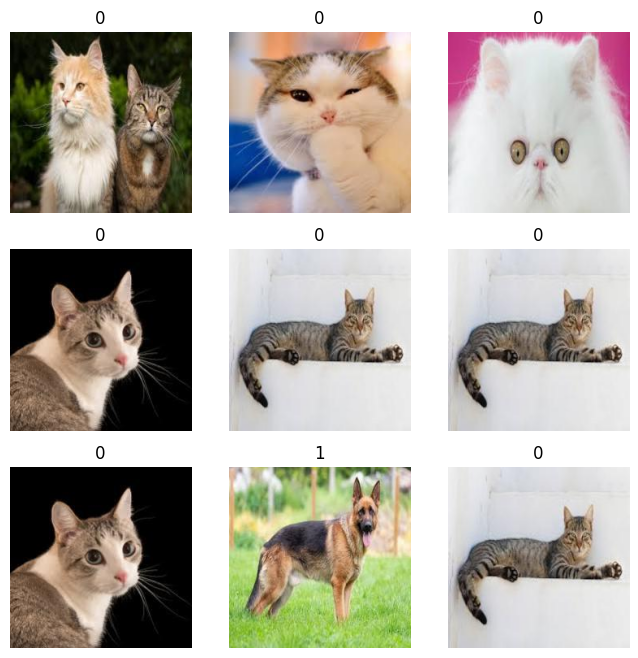

In [ ]:
# 【说明】随机可视化自定义数据集中的 9 张图片
# 通过标题和图片内容检查标签是否正确映射
# Lets get a visual of our dataset with 9 random images
import torch
import matplotlib.pyplot as plt
from PIL import Image


# Set up our plot
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(custom_dataset), size=(1,)).item()
    img, label = custom_dataset[sample_idx][2], custom_dataset[sample_idx][1]
    img = Image.open(img)
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img)
plt.show()

In [ ]:
# 【说明】为自定义数据集创建 DataLoader，后续训练时按 batch 迭代
# Create a DataLoader for our custom dataset
custom_dataloader = DataLoader(dataset=custom_dataset, batch_size=64, shuffle=True)

In [ ]:
# 【说明】从自定义 DataLoader 中取一个 batch，检查特征与标签张量形状
# Iterate through this dataloader like we did above
features, labels, urls = next(iter(custom_dataloader))
# Print the batch size and the number of labels
print(f"Features shape: {features.size()}")
print(f"Labels shape: {labels.size()}")

Features shape: torch.Size([10, 3, 224, 224])
Labels shape: torch.Size([10])


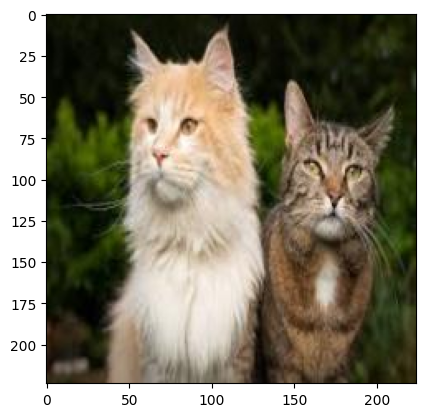

Label: 0 -> cat


In [ ]:
# 【说明】从 batch 中随机抽样一张图，显示图片并打印类别名称
# 这里 urls 保存的是图像路径，所以先 Image.open 再显示
# Show image with its label from a random image in our batch
import random

# Get a random value between 0 and our batch size
rand_indx = random.randint(0, labels.size()[0])

# set image and label
img = urls[rand_indx]
label = labels[rand_indx]

# Plot the image
img = Image.open(img)
plt.imshow(img)
plt.show()

# Print its label and map its numeric value to the actual name of its class
print(f"Label: {label} -> {custom_class_labels_map.get(label.item())}")

# Torchvision ImageFolder
Create a dataset using the folder structure as a way to label your images.

This utility simplifies the process of loading datasets where images are organized in a directory structure.

Example:
```bash
images/
    ├── cat/
    │   ├── cat1.jpg
    │   ├── cat2.jpg
    ├── dog/
    │   ├── dog1.jpg
    │   └── dog2.jpg
```

Each image will be labled by its directory.


In [ ]:
# 【说明】导入 torchvision，后续使用 ImageFolder 快速按目录结构构建数据集
# Import torchvision
import torchvision

In [ ]:
# 【说明】使用 ImageFolder 按目录自动打标签：子目录名即类别名
# 目录结构通常是 images/cat/*.jpg、images/dog/*.jpg
# Create a dataset using ImageFolder 
image_folder_dataset = torchvision.datasets.ImageFolder(
    root="images", # images directory
    transform=transforms.Compose([transforms.ToTensor()])) # Ignore this for now
print(image_folder_dataset)

Dataset ImageFolder
    Number of datapoints: 10
    Root location: images
    StandardTransform
Transform: Compose(
               ToTensor()
           )


In [ ]:
# 【说明】查看 ImageFolder 自动识别到的类别名
# Let's print the Classes of a dataset 
print(image_folder_dataset.classes)

['cat', 'dog']


In [ ]:
# 【说明】查看 ImageFolder 的类别到索引映射
# Print the classes to their indexes 
print(image_folder_dataset.class_to_idx)

{'cat': 0, 'dog': 1}


In [ ]:
# 【说明】把 ImageFolder 数据集包装成 DataLoader，统一训练数据输入方式
# Load into dataloader
image_folder_dataloader = DataLoader(image_folder_dataset, batch_size=64, shuffle=True)

In [ ]:
# 【说明】取出一个 batch（images, labels）用于后续可视化/训练
# Retrieve one batch of images and labels
images, labels = next(iter(image_folder_dataloader))


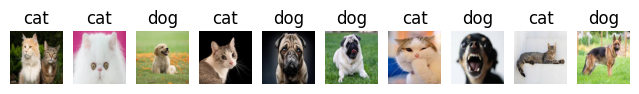

In [ ]:
# 【说明】可视化当前 batch 的图片并显示类别名
# img.permute(1, 2, 0) 是把张量从 [C,H,W] 调整为 matplotlib 需要的 [H,W,C]
# Plot the batch above
fig, axes = plt.subplots(1, len(images), figsize=(8, 8))

for i, (img, label) in enumerate(zip(images, labels)):
    img = img.permute(1, 2, 0) # Ignore this
    axes[i].imshow(img)
    axes[i].set_title(image_folder_dataset.classes[label])
    axes[i].axis("off")
plt.show()

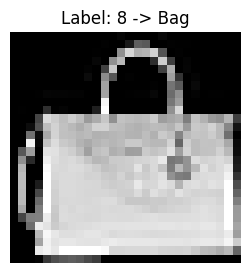

Image tensor shape: torch.Size([1, 28, 28])
Label index: 8
Label name: Bag


In [ ]:
# 【说明】额外示例：可视化 FashionMNIST 指定索引样本（这里是第 30 张）
# 并同时打印张量形状、标签索引和标签名称，帮助理解单样本结构
# Visualize the FashionMNIST sample
import matplotlib.pyplot as plt

img, label = image_dataset[30]

plt.figure(figsize=(3, 3))
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Label: {label} -> {image_dataset.classes[label]}")
plt.axis('off')
plt.show()

print('Image tensor shape:', img.shape)
print('Label index:', label)
print('Label name:', image_dataset.classes[label])